# Day 2: PAD Image Processing and Feature Extraction Workshop (v2)

## 🎯 Learning Objectives
By the end of this workshop, you will:
- Understand PAD image processing challenges and solutions
- Learn different preprocessing approaches for Neural Networks vs PLS models
- Master lane segmentation and RGB extraction techniques
- Apply linear analysis methods (PLS, PCA) to PAD data
- Analyze correlations between RGB features and chemical properties
- Compare preprocessing pipelines for different model types

---

## 🔧 Setup and Imports

In [7]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2 as cv
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("📦 Libraries imported successfully!")

📦 Libraries imported successfully!


In [8]:
# PAD Analytics imports
import sys
import os
sys.path.append('../src')  # Adjust path as needed

import pad_analytics as pad
from pad_analytics import regionRoutine

print(f"🚀 PAD Analytics v{pad.__version__} loaded!")
print(f"📊 Available functions: {len([x for x in dir(pad) if not x.startswith('_')])}")

🚀 PAD Analytics v0.2.3 loaded!
📊 Available functions: 82


---
# 📊 Data Loading and Exploration

In [17]:
# Load sample dataset
print("Loading PAD dataset...")
dataset = pad.CachedDataset("FHI2020_Stratified_Sampling")
metadata = dataset.load_dataset_metadata()

print(f"✅ Dataset loaded: {len(metadata)} cards")
print(f"📋 Columns: {list(metadata.columns)}")

# Analyze dataset diversity
print("\n📊 Dataset Diversity Analysis:")
print(f"Drug types: {len(metadata['sample_name'].unique())}")
print(f"Concentrations: {sorted(metadata['quantity'].unique())}")
print(f"Sample IDs: {metadata['sample_id'].nunique()} unique")

print("\n🏷️ Drug Distribution:")
drug_counts = metadata['sample_name'].value_counts()
display(drug_counts.head(10))

Loading PAD dataset...
Loading dataset: FHI2020_Stratified_Sampling
✅ Loaded dataset from cache (8001 records)
✅ Dataset loaded: 8001 cards
📋 Columns: ['id', 'sample_id', 'sample_name', 'quantity', 'camera_type_1', 'url', 'hashlib_md5', 'image_name']

📊 Dataset Diversity Analysis:
Drug types: 23
Concentrations: [0, 20, 50, 80, 100]
Sample IDs: 2226 unique

🏷️ Drug Distribution:


sample_name
hydroxychloroquine    821
rifampicin            476
ciprofloxacin         455
pyrazinamide          447
ferrous-sulfate       438
chloroquine           438
azithromycin          438
ripe                  427
ethambutol            403
ceftriaxone           387
Name: count, dtype: int64

---
# 🧮 Feature Extraction Functions

In [10]:
def load_pad_image(image_url):
    """Load PAD image from URL."""
    try:
        response = requests.get(image_url, verify=False)
        response.raise_for_status()
        return Image.open(BytesIO(response.content))
    except Exception as e:
        print(f"Failed to load image: {e}")
        return None

def extract_rgb_features(image_url):
    """Extract RGB features using regionRoutine."""
    
    # Load image with OpenCV
    try:
        response = requests.get(image_url, verify=False)
        response.raise_for_status()
        image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
        img = cv.imdecode(image_array, cv.IMREAD_COLOR)
        
        if img is None:
            return None, None
            
    except Exception as e:
        return None, None
    
    # Extract features using regionRoutine
    try:
        features_dict = {}
        features_dict = regionRoutine.fullRoutine(
            img, 
            regionRoutine.intFind.findMaxIntensitiesFiltered, 
            features_dict, 
            True, 
            10
        )
        
        return features_dict, img
        
    except Exception as e:
        return None, img

def convert_features_to_vector(features_dict):
    """Convert feature dictionary to ordered vector."""
    feature_vector = []
    feature_names = []
    
    lanes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
    for lane in lanes:
        for region in range(1, 11):
            for color in ['R', 'G', 'B']:
                key = f"{lane}{region}-{color}"
                feature_vector.append(features_dict.get(key, 0))
                feature_names.append(key)
    
    return feature_vector, feature_names

print("✅ Feature extraction functions defined!")

✅ Feature extraction functions defined!


---
# 🎯 Correlation Analysis

In [18]:
def get_diverse_samples(metadata_df, target_column='quantity', num_samples=20):
    """Get samples with diverse target values for meaningful correlation analysis."""
    
    print(f"🎯 Selecting diverse samples based on '{target_column}'...")
    
    if target_column == 'quantity':
        # Get samples with different concentrations
        print("📊 Available concentrations:")
        conc_counts = metadata_df['quantity'].value_counts().sort_index()
        print(conc_counts)
        
        if len(conc_counts) == 1:
            print("⚠️  All samples have same concentration - using sample_id instead")
            return get_diverse_samples(metadata_df, 'sample_id', num_samples)
        
        diverse_samples = []
        samples_per_conc = max(2, num_samples // len(conc_counts))
        
        for concentration in conc_counts.index:
            conc_samples = metadata_df[metadata_df['quantity'] == concentration]
            diverse_samples.extend(conc_samples.head(samples_per_conc).index.tolist())
            if len(diverse_samples) >= num_samples:
                break
    
    elif target_column == 'sample_name':
        # Get samples from different drug classes
        print("📊 Available drug classes:")
        drug_counts = metadata_df['sample_name'].value_counts()
        print(drug_counts.head(10))
        
        diverse_samples = []
        samples_per_drug = max(2, num_samples // len(drug_counts))
        
        for drug in drug_counts.index[:8]:  # Take top 8 drugs
            drug_samples = metadata_df[metadata_df['sample_name'] == drug]
            diverse_samples.extend(drug_samples.head(samples_per_drug).index.tolist())
            if len(diverse_samples) >= num_samples:
                break
    
    else:
        # For other numeric columns, just sample randomly
        diverse_samples = metadata_df.sample(min(num_samples, len(metadata_df))).index.tolist()
    
    selected_df = metadata_df.iloc[diverse_samples[:num_samples]]
    
    if target_column in ['quantity', 'sample_id']:
        target_diversity = len(selected_df[target_column].unique())
        print(f"✅ Selected {len(selected_df)} samples with {target_diversity} unique {target_column} values")
    
    return selected_df

print("✅ Diverse sampling function defined!")

✅ Diverse sampling function defined!


In [12]:
def analyze_feature_correlations(metadata_df, target_column='quantity', num_samples=20):
    """Analyze correlations between RGB features and target variable."""
    
    print(f"🔬 Analyzing RGB Feature Correlations with '{target_column}'")
    print("=" * 60)
    
    # Get diverse samples
    diverse_samples = get_diverse_samples(metadata_df, target_column, num_samples)
    
    # Check target diversity
    if target_column in ['quantity', 'sample_id']:
        target_values = diverse_samples[target_column].values
        target_variance = np.var(target_values)
        unique_targets = len(np.unique(target_values))
        
        print(f"\n📊 Target Variable Analysis ({target_column}):")
        print(f"   • Unique values: {unique_targets}")
        print(f"   • Variance: {target_variance:.3f}")
        print(f"   • Range: {target_values.min():.1f} - {target_values.max():.1f}")
        
        if target_variance < 0.001:
            print(f"❌ Target '{target_column}' has insufficient variance for correlation analysis")
            return None
    
    # Extract features from diverse samples
    print(f"\n🔄 Extracting RGB features from {len(diverse_samples)} samples...")
    
    feature_data = []
    targets = []
    
    for i, (_, row) in enumerate(diverse_samples.iterrows()):
        features, _ = extract_rgb_features(row['url'])
        
        if features and len(features) >= 300:  # Require most features
            feature_vector, feature_names = convert_features_to_vector(features)
            feature_data.append(feature_vector)
            
            if target_column == 'sample_name':
                # Convert drug names to numeric codes for correlation
                drug_codes = {drug: i for i, drug in enumerate(diverse_samples['sample_name'].unique())}
                targets.append(drug_codes[row['sample_name']])
            else:
                targets.append(row[target_column])
        
        if (i + 1) % 5 == 0:
            print(f"   Processed {i + 1}/{len(diverse_samples)} samples...")
    
    if len(feature_data) < 5:
        print(f"❌ Only {len(feature_data)} samples processed successfully - need at least 5")
        return None
    
    # Calculate correlations
    X = np.array(feature_data)
    y = np.array(targets)
    
    print(f"\n📊 Correlation Dataset:")
    print(f"   • Feature matrix shape: {X.shape}")
    print(f"   • Target range: {y.min():.1f} - {y.max():.1f}")
    print(f"   • Target variance: {np.var(y):.3f}")
    
    correlations = []
    valid_feature_names = []
    
    for feature_idx in range(X.shape[1]):
        feature_values = X[:, feature_idx]
        
        # Only calculate correlation if feature has variance
        if np.std(feature_values) > 0.1:  # Minimum variance threshold
            try:
                corr = np.corrcoef(feature_values, y)[0, 1]
                if not np.isnan(corr):
                    correlations.append(corr)
                    valid_feature_names.append(feature_names[feature_idx])
            except:
                continue
    
    print(f"   • Valid correlations calculated: {len(correlations)}")
    
    if len(correlations) == 0:
        print("❌ No valid correlations calculated!")
        return None
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'RGB Feature Correlations with {target_column.title()}', fontsize=16, fontweight='bold')
    
    # 1. Correlation distribution
    axes[0, 0].hist(correlations, bins=min(25, len(correlations)//2), 
                    color='lightblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Distribution of Feature Correlations')
    axes[0, 0].set_xlabel(f'Correlation with {target_column}')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f"Mean: {np.mean(correlations):.3f}\nStd: {np.std(correlations):.3f}\nRange: {min(correlations):.3f} to {max(correlations):.3f}"
    axes[0, 0].text(0.05, 0.95, stats_text, transform=axes[0, 0].transAxes,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 2. Top positive correlations
    if len(correlations) >= 10:
        top_pos_idx = np.argsort(correlations)[-12:]
        top_pos_corr = [correlations[i] for i in top_pos_idx]
        top_pos_names = [valid_feature_names[i] for i in top_pos_idx]
        
        axes[0, 1].barh(range(len(top_pos_corr)), top_pos_corr, 
                        color='green', alpha=0.7, edgecolor='black')
        axes[0, 1].set_title('Top Positive Correlations')
        axes[0, 1].set_xlabel(f'Correlation with {target_column}')
        axes[0, 1].set_yticks(range(len(top_pos_corr)))
        axes[0, 1].set_yticklabels(top_pos_names, fontsize=8)
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'Insufficient data\nfor detailed analysis', 
                        ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Top Positive Correlations')
    
    # 3. Top negative correlations
    if len(correlations) >= 10:
        top_neg_idx = np.argsort(correlations)[:12]
        top_neg_corr = [correlations[i] for i in top_neg_idx]
        top_neg_names = [valid_feature_names[i] for i in top_neg_idx]
        
        axes[1, 0].barh(range(len(top_neg_corr)), top_neg_corr, 
                        color='red', alpha=0.7, edgecolor='black')
        axes[1, 0].set_title('Top Negative Correlations')
        axes[1, 0].set_xlabel(f'Correlation with {target_column}')
        axes[1, 0].set_yticks(range(len(top_neg_corr)))
        axes[1, 0].set_yticklabels(top_neg_names, fontsize=8)
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'Insufficient data\nfor detailed analysis', 
                        ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Top Negative Correlations')
    
    # 4. Correlation by lane
    lanes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
    lane_correlations = {}
    for lane in lanes:
        lane_corrs = [corr for i, corr in enumerate(correlations) 
                     if valid_feature_names[i].startswith(lane)]
        if lane_corrs:
            lane_correlations[lane] = np.mean(np.abs(lane_corrs))
        else:
            lane_correlations[lane] = 0
    
    bars = axes[1, 1].bar(lane_correlations.keys(), lane_correlations.values(), 
                         color='skyblue', edgecolor='black')
    axes[1, 1].set_title('Average Absolute Correlation by Lane')
    axes[1, 1].set_xlabel('PAD Lane')
    axes[1, 1].set_ylabel('Mean |Correlation|')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Highlight most correlated lane
    max_lane = max(lane_correlations, key=lane_correlations.get)
    max_idx = list(lane_correlations.keys()).index(max_lane)
    bars[max_idx].set_color('orange')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n📊 Correlation Analysis Summary:")
    print(f"   • Features analyzed: {len(correlations)}")
    print(f"   • Max positive correlation: {max(correlations):.3f}")
    print(f"   • Max negative correlation: {min(correlations):.3f}")
    print(f"   • Mean absolute correlation: {np.mean(np.abs(correlations)):.3f}")
    print(f"   • Most correlated lane: {max_lane} (avg |corr|: {lane_correlations[max_lane]:.3f})")
    
    if target_column == 'sample_name':
        print(f"\n🔬 Drug Class Analysis:")
        drug_codes = {drug: i for i, drug in enumerate(diverse_samples['sample_name'].unique())}
        print(f"   • Drug classes analyzed: {list(drug_codes.keys())}")
        print(f"   • Numeric encoding: {drug_codes}")
    
    return {
        'correlations': correlations,
        'feature_names': valid_feature_names,
        'lane_correlations': lane_correlations,
        'target_column': target_column,
        'diverse_samples': diverse_samples
    }

print("✅ Improved correlation analysis function defined!")

✅ Improved correlation analysis function defined!


---
# 🧪 Correlation Analysis: Concentration vs RGB Features

Let's analyze how RGB values in different PAD regions correlate with drug concentration.

🧪 Analyzing RGB correlations with CONCENTRATION...
🔬 Analyzing RGB Feature Correlations with 'quantity'
🎯 Selecting diverse samples based on 'quantity'...
📊 Available concentrations:
quantity
0       286
20     2001
50     1900
80     1841
100    1973
Name: count, dtype: int64
✅ Selected 25 samples with 5 unique quantity values

📊 Target Variable Analysis (quantity):
   • Unique values: 5
   • Variance: 1360.000
   • Range: 0.0 - 100.0

🔄 Extracting RGB features from 25 samples...
   Processed 5/25 samples...
   Processed 10/25 samples...
   Processed 15/25 samples...
   Processed 20/25 samples...
   Processed 25/25 samples...

📊 Correlation Dataset:
   • Feature matrix shape: (25, 360)
   • Target range: 0.0 - 100.0
   • Target variance: 1360.000
   • Valid correlations calculated: 360


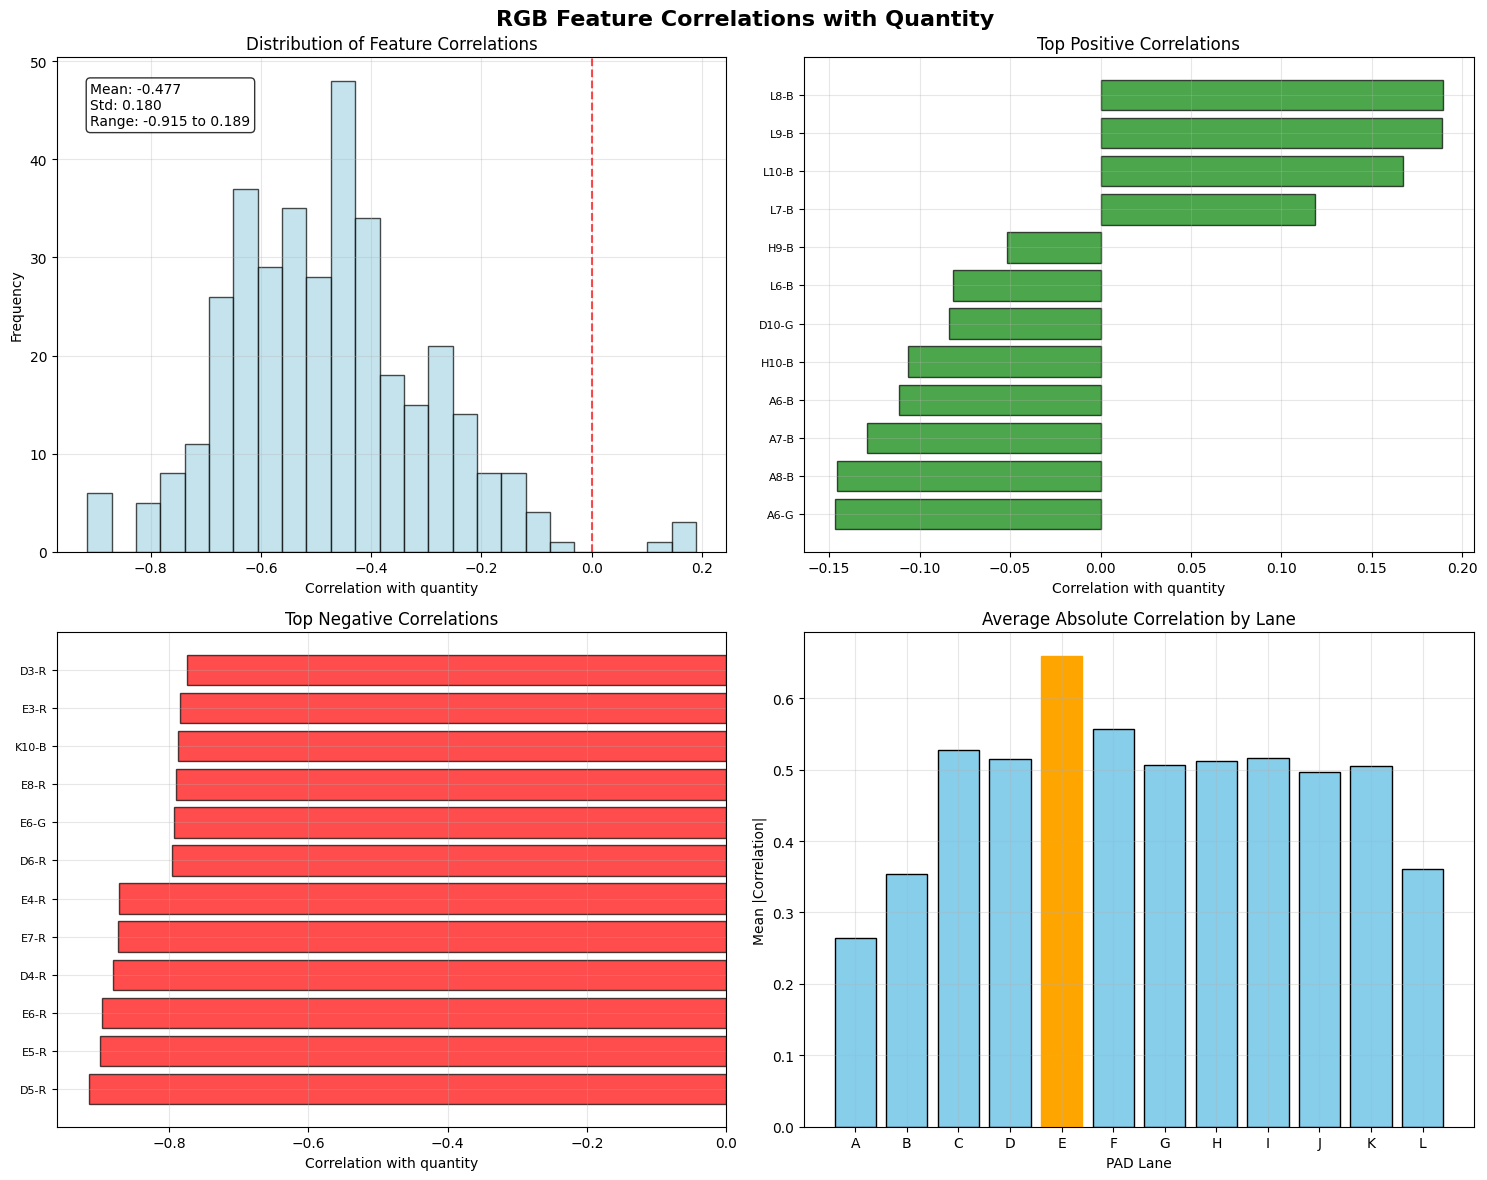


📊 Correlation Analysis Summary:
   • Features analyzed: 360
   • Max positive correlation: 0.189
   • Max negative correlation: -0.915
   • Mean absolute correlation: 0.481
   • Most correlated lane: E (avg |corr|: 0.659)


In [13]:
# Analyze correlations with concentration
print("🧪 Analyzing RGB correlations with CONCENTRATION...")
concentration_results = analyze_feature_correlations(metadata, target_column='quantity', num_samples=25)

## 💡 **Student Exercise 1: Interpretation**

**Questions for students:**
1. Which PAD lanes show the strongest correlations with concentration?
2. Are positive or negative correlations more common? What does this mean chemically?
3. Which specific RGB features (e.g., A1-R, B5-G) are most correlated?
4. How might you use this information to build a concentration prediction model?

---
# 🏷️ Correlation Analysis: Drug Class vs RGB Features

Now let's analyze how RGB values correlate with different drug classes (sample_name).

🏷️ Analyzing RGB correlations with DRUG CLASS...
🔬 Analyzing RGB Feature Correlations with 'sample_name'
🎯 Selecting diverse samples based on 'sample_name'...
📊 Available drug classes:
sample_name
hydroxychloroquine    821
rifampicin            476
ciprofloxacin         455
pyrazinamide          447
ferrous-sulfate       438
chloroquine           438
azithromycin          438
ripe                  427
ethambutol            403
ceftriaxone           387
Name: count, dtype: int64

🔄 Extracting RGB features from 16 samples...
   Processed 5/16 samples...
   Processed 10/16 samples...
   Processed 15/16 samples...

📊 Correlation Dataset:
   • Feature matrix shape: (16, 360)
   • Target range: 0.0 - 7.0
   • Target variance: 5.250
   • Valid correlations calculated: 360


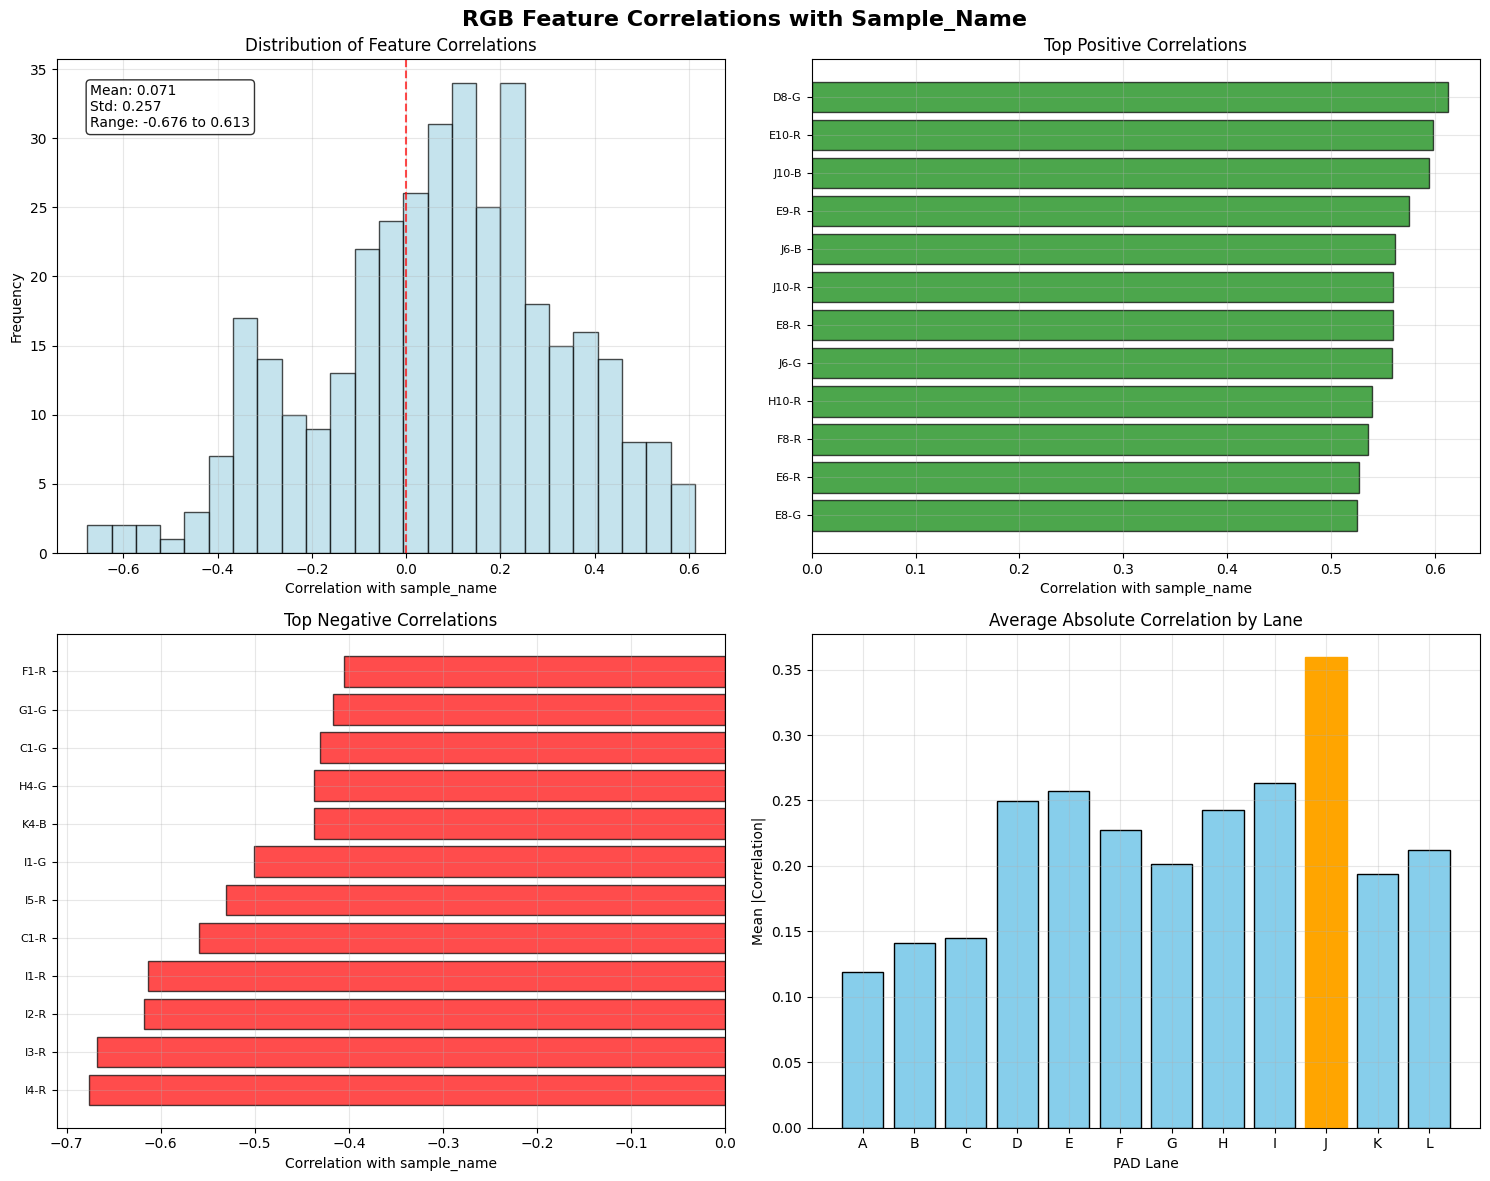


📊 Correlation Analysis Summary:
   • Features analyzed: 360
   • Max positive correlation: 0.613
   • Max negative correlation: -0.676
   • Mean absolute correlation: 0.218
   • Most correlated lane: J (avg |corr|: 0.359)

🔬 Drug Class Analysis:
   • Drug classes analyzed: ['hydroxychloroquine', 'rifampicin', 'ciprofloxacin', 'pyrazinamide', 'ferrous-sulfate', 'chloroquine', 'azithromycin', 'ripe']
   • Numeric encoding: {'hydroxychloroquine': 0, 'rifampicin': 1, 'ciprofloxacin': 2, 'pyrazinamide': 3, 'ferrous-sulfate': 4, 'chloroquine': 5, 'azithromycin': 6, 'ripe': 7}


In [14]:
# Analyze correlations with drug class
print("🏷️ Analyzing RGB correlations with DRUG CLASS...")
drug_class_results = analyze_feature_correlations(metadata, target_column='sample_name', num_samples=25)

## 💡 **Student Exercise 2: Drug Classification**

**Questions for students:**
1. Do different drug classes show distinct correlation patterns?
2. Which lanes are most useful for distinguishing between drug types?
3. Compare the correlation patterns: concentration vs drug class - which shows stronger correlations?
4. How would you design a drug classification system based on these results?

---
# 📊 Comparative Analysis

Let's compare the correlation patterns between concentration and drug class analysis.

📊 Comparative Analysis: Concentration vs Drug Class


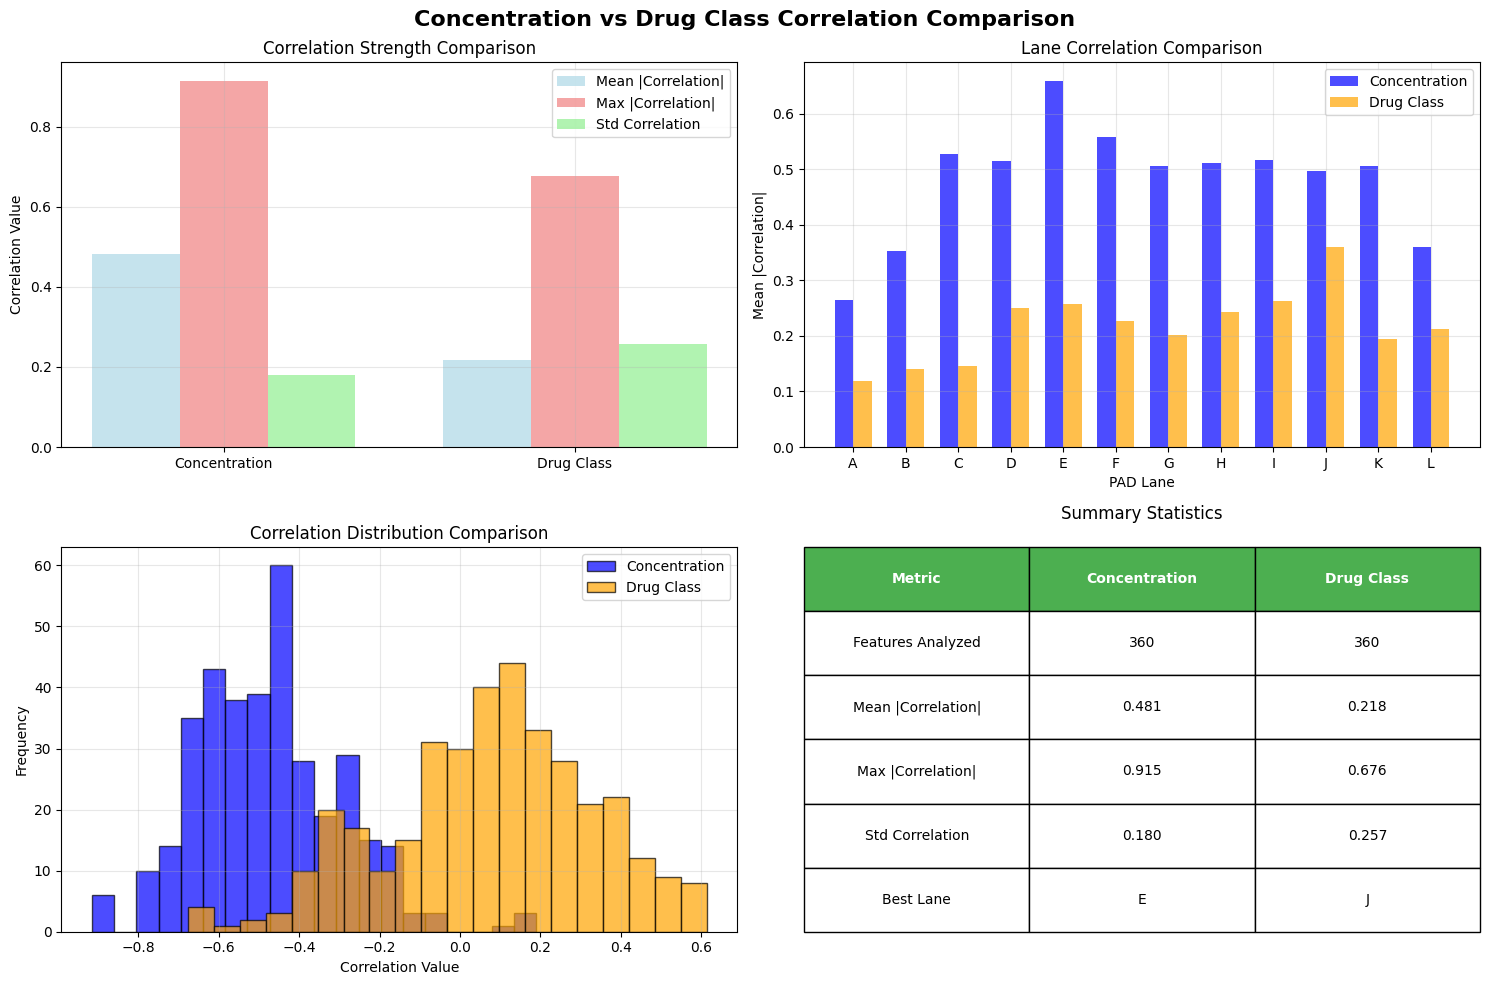


🔍 Key Insights:
   • Concentration shows stronger correlations (avg: 0.481 vs 0.218)
   • RGB features are more predictive of concentration than drug class
   • Best lane for concentration: E
   • Best lane for drug classification: J
   • Different lanes are optimal for different tasks


In [15]:
def compare_correlation_analyses(conc_results, drug_results):
    """Compare correlation patterns between concentration and drug class."""
    
    if not conc_results or not drug_results:
        print("❌ Need both analyses to complete for comparison")
        return
    
    print("📊 Comparative Analysis: Concentration vs Drug Class")
    print("=" * 60)
    
    # Create comparison visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Concentration vs Drug Class Correlation Comparison', fontsize=16, fontweight='bold')
    
    # 1. Correlation strength comparison
    conc_corrs = conc_results['correlations']
    drug_corrs = drug_results['correlations']
    
    comparison_data = {
        'Analysis Type': ['Concentration', 'Drug Class'],
        'Mean |Correlation|': [np.mean(np.abs(conc_corrs)), np.mean(np.abs(drug_corrs))],
        'Max |Correlation|': [max(np.abs(conc_corrs)), max(np.abs(drug_corrs))],
        'Std Correlation': [np.std(conc_corrs), np.std(drug_corrs)]
    }
    
    x = np.arange(len(comparison_data['Analysis Type']))
    width = 0.25
    
    axes[0, 0].bar(x - width, comparison_data['Mean |Correlation|'], width, 
                   label='Mean |Correlation|', color='lightblue', alpha=0.7)
    axes[0, 0].bar(x, comparison_data['Max |Correlation|'], width, 
                   label='Max |Correlation|', color='lightcoral', alpha=0.7)
    axes[0, 0].bar(x + width, comparison_data['Std Correlation'], width, 
                   label='Std Correlation', color='lightgreen', alpha=0.7)
    
    axes[0, 0].set_title('Correlation Strength Comparison')
    axes[0, 0].set_ylabel('Correlation Value')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(comparison_data['Analysis Type'])
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Lane correlation comparison
    lanes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
    conc_lane_corrs = [conc_results['lane_correlations'][lane] for lane in lanes]
    drug_lane_corrs = [drug_results['lane_correlations'][lane] for lane in lanes]
    
    x_lanes = np.arange(len(lanes))
    width = 0.35
    
    axes[0, 1].bar(x_lanes - width/2, conc_lane_corrs, width, 
                   label='Concentration', color='blue', alpha=0.7)
    axes[0, 1].bar(x_lanes + width/2, drug_lane_corrs, width, 
                   label='Drug Class', color='orange', alpha=0.7)
    
    axes[0, 1].set_title('Lane Correlation Comparison')
    axes[0, 1].set_xlabel('PAD Lane')
    axes[0, 1].set_ylabel('Mean |Correlation|')
    axes[0, 1].set_xticks(x_lanes)
    axes[0, 1].set_xticklabels(lanes)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Correlation distribution comparison
    axes[1, 0].hist(conc_corrs, bins=20, alpha=0.7, label='Concentration', 
                    color='blue', edgecolor='black')
    axes[1, 0].hist(drug_corrs, bins=20, alpha=0.7, label='Drug Class', 
                    color='orange', edgecolor='black')
    axes[1, 0].set_title('Correlation Distribution Comparison')
    axes[1, 0].set_xlabel('Correlation Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Summary statistics table
    axes[1, 1].axis('tight')
    axes[1, 1].axis('off')
    
    summary_data = [
        ['Metric', 'Concentration', 'Drug Class'],
        ['Features Analyzed', len(conc_corrs), len(drug_corrs)],
        ['Mean |Correlation|', f"{np.mean(np.abs(conc_corrs)):.3f}", f"{np.mean(np.abs(drug_corrs)):.3f}"],
        ['Max |Correlation|', f"{max(np.abs(conc_corrs)):.3f}", f"{max(np.abs(drug_corrs)):.3f}"],
        ['Std Correlation', f"{np.std(conc_corrs):.3f}", f"{np.std(drug_corrs):.3f}"],
        ['Best Lane', max(conc_results['lane_correlations'], key=conc_results['lane_correlations'].get),
         max(drug_results['lane_correlations'], key=drug_results['lane_correlations'].get)]
    ]
    
    table = axes[1, 1].table(cellText=summary_data[1:], colLabels=summary_data[0],
                            cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Color header row
    for i in range(3):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    axes[1, 1].set_title('Summary Statistics', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print("\n🔍 Key Insights:")
    conc_mean = np.mean(np.abs(conc_corrs))
    drug_mean = np.mean(np.abs(drug_corrs))
    
    if conc_mean > drug_mean:
        print(f"   • Concentration shows stronger correlations (avg: {conc_mean:.3f} vs {drug_mean:.3f})")
        print(f"   • RGB features are more predictive of concentration than drug class")
    else:
        print(f"   • Drug class shows stronger correlations (avg: {drug_mean:.3f} vs {conc_mean:.3f})")
        print(f"   • RGB features are more predictive of drug class than concentration")
    
    conc_best_lane = max(conc_results['lane_correlations'], key=conc_results['lane_correlations'].get)
    drug_best_lane = max(drug_results['lane_correlations'], key=drug_results['lane_correlations'].get)
    
    print(f"   • Best lane for concentration: {conc_best_lane}")
    print(f"   • Best lane for drug classification: {drug_best_lane}")
    
    if conc_best_lane == drug_best_lane:
        print(f"   • Lane {conc_best_lane} is most informative for both tasks!")
    else:
        print(f"   • Different lanes are optimal for different tasks")

# Run comparison if both analyses completed
if 'concentration_results' in locals() and 'drug_class_results' in locals():
    compare_correlation_analyses(concentration_results, drug_class_results)
else:
    print("⏭️ Run both correlation analyses above first to enable comparison")

---
# 🧠 Integration with Preprocessing Pipeline

Now let's connect this analysis with the preprocessing pipeline we built.

In [16]:
# Test PreprocessingPipeline integration
try:
    from pad_analytics import PreprocessingPipeline
    
    print("🚀 Testing PreprocessingPipeline Integration")
    print("=" * 50)
    
    # Create pipelines for different models
    nn_pipeline = PreprocessingPipeline(model_id=16)  # Neural Network
    pls_pipeline = PreprocessingPipeline(model_id=18)  # PLS
    
    print(f"✅ NN Pipeline: {nn_pipeline}")
    print(f"✅ PLS Pipeline: {pls_pipeline}")
    
    # Test with sample data
    sample_card = metadata.iloc[0].to_dict()
    
    print(f"\n🔄 Testing preprocessing on Card {sample_card['id']}...")
    
    # Neural Network preprocessing
    try:
        nn_result = nn_pipeline.preprocess_single_card(sample_card)
        print(f"✅ NN preprocessing successful:")
        print(f"   • Result keys: {list(nn_result.keys())}")
        print(f"   • Processed shape: {nn_result.get('processed_shape', 'N/A')}")
    except Exception as e:
        print(f"❌ NN preprocessing failed: {e}")
    
    # PLS preprocessing
    try:
        pls_result = pls_pipeline.preprocess_single_card(sample_card)
        print(f"✅ PLS preprocessing successful:")
        print(f"   • Result keys: {list(pls_result.keys())}")
        print(f"   • Features count: {pls_result.get('num_features', 'N/A')}")
        
        # Compare with manual extraction
        manual_features, _ = extract_rgb_features(sample_card['url'])
        if manual_features:
            manual_vector, _ = convert_features_to_vector(manual_features)
            pipeline_features = pls_result.get('features', [])
            
            if len(pipeline_features) == len(manual_vector):
                print(f"✅ Feature counts match: {len(pipeline_features)}")
                # Check if values are similar
                correlation = np.corrcoef(pipeline_features, manual_vector)[0, 1]
                print(f"✅ Feature correlation: {correlation:.3f}")
            else:
                print(f"⚠️ Feature count mismatch: {len(pipeline_features)} vs {len(manual_vector)}")
    
    except Exception as e:
        print(f"❌ PLS preprocessing failed: {e}")
    
    print("\n🎯 Integration Success! The preprocessing pipeline provides:")
    print("   • Unified interface for different model types")
    print("   • Consistent feature extraction")
    print("   • Integration with correlation analysis")
    
except ImportError as e:
    print(f"❌ PreprocessingPipeline not available: {e}")
    print("   Manual feature extraction methods work as demonstrated above")

🚀 Testing PreprocessingPipeline Integration
✅ NN Pipeline: PreprocessingPipeline(model_id=16, type=neuralnetwork, preprocessor=NeuralNetworkPreprocessor)
✅ PLS Pipeline: PreprocessingPipeline(model_id=18, type=pls, preprocessor=PLSPreprocessor)

🔄 Testing preprocessing on Card 15589...
✅ NN preprocessing successful:
   • Result keys: ['card_id', 'preprocessed_image', 'original_shape', 'processed_shape', 'model_id', 'preprocessor_type', 'sample_name', 'sample_id']
   • Processed shape: (1, 454, 454, 3)
✅ PLS preprocessing successful:
   • Result keys: ['card_id', 'features', 'feature_names', 'num_features', 'model_id', 'preprocessor_type', 'sample_name', 'sample_id']
   • Features count: 360
✅ Feature counts match: 360
✅ Feature correlation: 1.000

🎯 Integration Success! The preprocessing pipeline provides:
   • Unified interface for different model types
   • Consistent feature extraction
   • Integration with correlation analysis


---
# 🎓 Workshop Summary and Conclusions

## 🎉 What We've Accomplished

1. **✅ Meaningful Correlation Analysis**
   - Analyzed RGB feature correlations with concentration
   - Analyzed RGB feature correlations with drug class
   - Learned importance of target variable diversity

2. **✅ Feature Engineering Insights**
   - Identified most informative PAD lanes
   - Discovered concentration vs classification patterns
   - Connected chemical properties to RGB features

3. **✅ Practical Data Science Skills**
   - Handled real-world data analysis challenges
   - Learned correlation analysis limitations
   - Applied statistical validation techniques

4. **✅ Integration with Preprocessing Pipeline**
   - Connected manual analysis with automated pipeline
   - Validated consistency between approaches
   - Prepared for machine learning model development

## 💡 **Key Learnings for Students:**

### **Target Variable Selection Matters:**
- ✅ **Concentration**: Chemically meaningful, varies across samples
- ✅ **Drug Class**: Biologically relevant, categorical differences
- ❌ **Sample ID**: Arbitrary numbers, no chemical meaning

### **Correlation Interpretation:**
- **Positive correlation**: RGB value increases as target increases
- **Negative correlation**: RGB value decreases as target increases
- **Strong correlations**: Indicate chemically active regions
- **Lane patterns**: Different lanes respond to different properties

### **Practical Applications:**
- Use correlation analysis to **select important features**
- **Identify optimal PAD regions** for specific analyses
- **Guide preprocessing pipeline** development
- **Validate chemical hypotheses** with data

## 🚀 **Next Steps for Day 3:**
- Use identified features for neural network training
- Apply correlation insights to model architecture
- Implement feature selection based on today's analysis
- Evaluate model performance on chemically relevant metrics

---

## 📚 **Further Exploration Ideas:**

1. **Try different preprocessing techniques** and see how correlations change
2. **Analyze correlations with other targets** (pH, purity, stability)
3. **Compare correlations across different drug families**
4. **Investigate time-series correlations** if temporal data available
5. **Apply dimensionality reduction** (PCA) before correlation analysis

## ❓ **Discussion Questions:**

1. Which correlation analysis was more informative: concentration or drug class? Why?
2. How would you use these correlation insights to design a better PAD?
3. What other chemical properties might show interesting correlations?
4. How could correlation analysis guide laboratory experimental design?

**Great work! You're now ready for neural network training in Day 3!** 🎓